En el presente documento de busca saber qué día de Semana Santa es en el que se ha reportado mayor préstamo de bicicletas en la Ciudad de México.

In [45]:
import pandas as pd
import numpy as np
import sklearn as sk

In [2]:
df = pd.read_csv("datos_limpios.csv", sep=',')
df=pd.DataFrame(df)

df

C:\Users\aripi\AppData\Local\Temp\ipykernel_50244\3481539578.py:1: DtypeWarning: Columns (0,2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("datos_limpios.csv", sep=',')


,Ciclo_Estacion_Retiro,Fecha_Retiro,Ciclo_Estacion_Arribo
0,52,2015-03-29,35
1,52,2015-03-29,35
2,208,2015-03-29,206
3,59,2015-03-29,141
4,59,2015-03-29,141
...,...,...,...
1826697,611,2025-04-20,562
1826698,180,2025-04-20,393
1826699,493,2025-04-20,261
1826700,354,2025-04-20,290


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1826702 entries, 0 to 1826701
Data columns (total 3 columns):
 #   Column                 Dtype 
---  ------                 ----- 
 0   Ciclo_Estacion_Retiro  object
 1   Fecha_Retiro           object
 2   Ciclo_Estacion_Arribo  object
dtypes: object(3)
memory usage: 41.8+ MB


Análisis de NaN:

In [6]:
total_filas = len(df)

# Resumen de faltantes por columna
faltantes_resumen = pd.DataFrame({
    "faltantes": df.isna().sum(),
    "porcentaje_faltantes": (df.isna().sum() / total_filas) * 100
})

# Opcional: ordenar de mayor a menor porcentaje de faltantes
faltantes_resumen = faltantes_resumen.sort_values(by="porcentaje_faltantes", ascending=False)

# Opcional: redondear porcentaje a 2 decimales
faltantes_resumen["porcentaje_faltantes"] = faltantes_resumen["porcentaje_faltantes"].round(2)

faltantes_resumen

,faltantes,porcentaje_faltantes
Ciclo_Estacion_Retiro,0,0.0
Fecha_Retiro,0,0.0
Ciclo_Estacion_Arribo,0,0.0


Se observa que el presente dataframe no tiene datos faltantes (NaN).

In [11]:
df.describe(include="all")

,Ciclo_Estacion_Retiro,Fecha_Retiro,Ciclo_Estacion_Arribo
count,1826702,1826702,1826702
unique,1901,88,1903
top,27,2024-03-26,271-272
freq,9246,66491,13634


Se procede a agrupar las fechas por año:

In [12]:
def convertir_fechas(df):
    
    df["Fecha_Retiro"] = pd.to_datetime(
        df["Fecha_Retiro"],
        errors="coerce"   # convierte errores en NaT
    )
    
    return df

In [13]:
convertir_fechas(df)

,Ciclo_Estacion_Retiro,Fecha_Retiro,Ciclo_Estacion_Arribo
0,52,2015-03-29,35
1,52,2015-03-29,35
2,208,2015-03-29,206
3,59,2015-03-29,141
4,59,2015-03-29,141
...,...,...,...
1826697,611,2025-04-20,562
1826698,180,2025-04-20,393
1826699,493,2025-04-20,261
1826700,354,2025-04-20,290


In [57]:
#def vt(df):
#    
#    df["año"] = df["Fecha_Retiro"].dt.year
#    df["mes"] = df["Fecha_Retiro"].dt.month
#    df["dia"] = df["Fecha_Retiro"].dt.day
    
#    df["dia_semana"] = df["Fecha_Retiro"].dt.day_name()
#    df["es_fin_semana"] = df["Fecha_Retiro"].isin(["Saturday", "Sunday"])
    
    
#    return df

In [58]:
#vt(df)

In [99]:
def agrupar_por_dia(df):
    
    prestamos_diarios = (
        df.groupby("Fecha_Retiro")
        .size()
        .reset_index(name="num_Retiros")
    )
    
    return prestamos_diarios

In [100]:
df1=agrupar_por_dia(df)
df1["año"] = df1["Fecha_Retiro"].dt.year
df1["mes"] = df1["Fecha_Retiro"].dt.month
df1["dia"] = df1["Fecha_Retiro"].dt.day
df1

,Fecha_Retiro,num_Retiros,año,mes,dia
0,2015-03-29,11915,2015,3,29
1,2015-03-30,29726,2015,3,30
2,2015-03-31,30852,2015,3,31
3,2015-04-01,23860,2015,4,1
4,2015-04-02,11522,2015,4,2
...,...,...,...,...,...
83,2025-04-16,57245,2025,4,16
84,2025-04-17,40971,2025,4,17
85,2025-04-18,35690,2025,4,18
86,2025-04-19,35250,2025,4,19


La tabla anterior muestra el número de retiros por día desde el 2015 al 2025 durante la Semana Santa.

In [121]:
df = df.copy()
    
df["fecha"] = pd.to_datetime(df["Fecha_Retiro"])
    
    # préstamos diarios
df_diario = (
    df.groupby("fecha")
    .size()
    .reset_index(name="num_prestamos")
    )
    
df_diario["dia_semana"] = df_diario["fecha"].dt.day_name()
df_diario["dia_semana_num"] = df_diario["fecha"].dt.weekday

In [122]:
df_diario

,fecha,num_prestamos,dia_semana,dia_semana_num
0,2015-03-29,11915,Sunday,6
1,2015-03-30,29726,Monday,0
2,2015-03-31,30852,Tuesday,1
3,2015-04-01,23860,Wednesday,2
4,2015-04-02,11522,Thursday,3
...,...,...,...,...
83,2025-04-16,57245,Wednesday,2
84,2025-04-17,40971,Thursday,3
85,2025-04-18,35690,Friday,4
86,2025-04-19,35250,Saturday,5


In [123]:
def patron_semanal(df_diario):
    
    patron = (
        df_diario.groupby("dia_semana_num")["num_prestamos"]
        .mean()
        .reset_index()
    )
    
    dias = ["Lunes","Martes","Miércoles","Jueves","Viernes","Sábado","Domingo"]
    patron["dia"] = patron["dia_semana_num"].apply(lambda x: dias[x])
    
    return patron.sort_values("dia_semana_num")

In [124]:
patron_semanal(df_diario)

,dia_semana_num,num_prestamos,dia
0,0,28232.727273,Lunes
1,1,30325.818182,Martes
2,2,28324.545455,Miércoles
3,3,16698.363636,Jueves
4,4,14432.363636,Viernes
5,5,15265.545455,Sábado
6,6,16392.227273,Domingo


In [125]:
import matplotlib.pyplot as plt

def plot_patron(patron):
    
    plt.figure(figsize=(8,4))
    
    plt.plot(patron["dia"], patron["num_prestamos"], marker='o')
    
    plt.title("Patrón semanal de demanda")
    plt.xlabel("Día de la semana")
    plt.ylabel("Promedio de préstamos")
    plt.grid(True)
    
    plt.show()

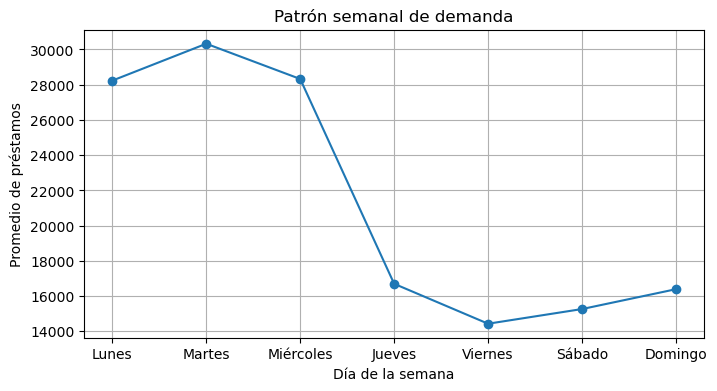

In [126]:
plot_patron(patron_semanal(df_diario))